In [1]:
#%matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
from pathlib import Path
import supervision as sv

### Punto 1

En una primera instancia se realiza una exploración del template, aplicando una inversión de bits de negro a blanco y posteriormente una transformación de contraste y brillo. Este preprocesamiento tiene como finalidad obtener una versión del logo más similar a las condiciones visuales presentes en las imágenes donde se intentará detectarlo, mejorando así la extracción de características en etapas posteriores.

El algoritmo desarrollado se plantea de la siguiente forma. En primer lugar, al template se le aplica el preprocesamiento definido en la etapa exploratoria, con el fin de resaltar sus patrones característicos. Luego, mediante SIFT, se extraen los puntos característicos clave (keypoints) y sus descriptores tanto del template procesado como de la imagen de búsqueda. Posteriormente, se emplea FLANN para comparar ambos conjuntos de descriptores, obteniendo los dos vecinos más cercanos (k = 2) para cada descriptor y habilitando así la aplicación del Lowe’s Ratio Test, el cual filtra coincidencias poco confiables y permite conservar únicamente los emparejamientos más precisos. Para continuar con la detección, se exige un mínimo de 8 correspondencias válidas (MIN_MATCH_COUNT), ya que esta cantidad representa el umbral mínimo necesario para estimar una transformación robusta entre ambas imágenes. Cumplido este criterio, se procede a la estimación de la homografía utilizando RANSAC, que permite obtener una matriz de transformación libre de outliers al quedarse únicamente con los puntos coherentes (inliers). Con dicha homografía se realiza la deformación proyectiva del template sobre la imagen de búsqueda, permitiendo visualizar con precisión la región donde se detecta el logo. Finalmente, si la detección falla en el primer intento, el algoritmo ejecuta un segundo análisis invirtiendo los valores de la imagen de búsqueda, dado que se observó que algunas variantes del logo pueden aparecer con colores temple_invs. Este reintento incrementa la robustez y confiabilidad del proceso de detección.

Por último, el algoritmo se aplica sobre el conjunto completo de imágenes, generando para cada una la visualización correspondiente de la detección y los descriptores asociados. El método logró identificar el logo de forma exitosa en todas las imágenes analizadas, con excepción del caso coca_multi.png, donde no se alcanzó un número suficiente de correspondencias válidas para estimar una homografía confiable y, por lo tanto, no se pudo completar la detección.


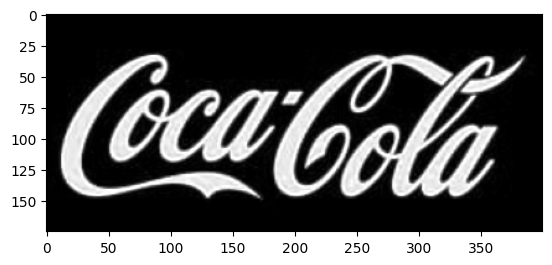

In [2]:
img1 = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('images/coca_logo_2.png', cv.IMREAD_GRAYSCALE)
img1_inverted = cv.bitwise_not(img1)
img1_enhanced = cv.convertScaleAbs(img1_inverted, alpha=1.7, beta=30)
plt.imshow(img1_enhanced, cmap='gray')


In [3]:
def detectar_logo(img_template, img_search):

    sift = cv.SIFT_create()
    intentos = [
        ("original", img_search),
        ("invertida", cv.bitwise_not(img_search))
    ]
    
    for intento_nombre, img_actual in intentos:
        
        # SIFT
        kp1, des1 = sift.detectAndCompute(img_template, None)
        kp2, des2 = sift.detectAndCompute(img_actual, None)
        
        print(f"Keypoints template: {len(kp1)}")
        print(f"Keypoints search ({intento_nombre}): {len(kp2)}")
        
        if des1 is None or des2 is None:
            print(f"Descriptores insuficientes ({intento_nombre})")
            continue
        
        # FLANN
        FLANN_INDEX_KDTREE = 1
        flann = cv.FlannBasedMatcher(
            dict(algorithm=FLANN_INDEX_KDTREE, trees=5),
            dict(checks=50)
        )
        matches = flann.knnMatch(des1, des2, k=2)
        good = []
        for match_pair in matches:
            if len(match_pair) == 2:
                m, n = match_pair
                if m.distance < 0.7 * n.distance:
                    good.append(m)
        
        print(f"Matches buenos: {len(good)}")
        
        # Homografía 
        MIN_MATCH_COUNT = 8
        if len(good) < MIN_MATCH_COUNT:
            print(f"Matches insuficientes ({intento_nombre})")
            continue
        
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        
        if M is None:
            print(f"Homografía no válida ({intento_nombre})")
            continue
        
        # Esquinas transformadas
        h, w = img_template.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        dst = cv.perspectiveTransform(pts, M)
        
        inliers = sum(mask.ravel())
        print(f"Inliers: {inliers}/{len(good)}")
        print(f"Detección exitosa ({intento_nombre})")
        
        return {
            'keypoints1': kp1,
            'keypoints2': kp2,
            'matches': good,
            'mask': mask,
            'puntos_esquina': dst,
            'homografia': M,
            'intento': intento_nombre
        }
    
    print("\nNo se pudo detectar el logo en ningún intento")
    return None



Procesando: COCA-COLA-LOGO.jpg
Keypoints template: 172
Keypoints search (original): 2848
Matches buenos: 35
Inliers: 18/35
Detección exitosa (original)

Procesando: coca_logo_1.png
Keypoints template: 172
Keypoints search (original): 289
Matches buenos: 37
Inliers: 31/37
Detección exitosa (original)

Procesando: coca_logo_2.png
Keypoints template: 172
Keypoints search (original): 615
Matches buenos: 34
Inliers: 26/34
Detección exitosa (original)

Procesando: coca_multi.png
Keypoints template: 172
Keypoints search (original): 4046
Matches buenos: 2
Matches insuficientes (original)
Keypoints template: 172
Keypoints search (invertida): 4048
Matches buenos: 0
Matches insuficientes (invertida)

No se pudo detectar el logo en ningún intento
No se detectó logo en coca_multi.png


Procesando: coca_retro_1.png
Keypoints template: 172
Keypoints search (original): 3892
Matches buenos: 2
Matches insuficientes (original)
Keypoints template: 172
Keypoints search (invertida): 3894
Matches buenos: 26

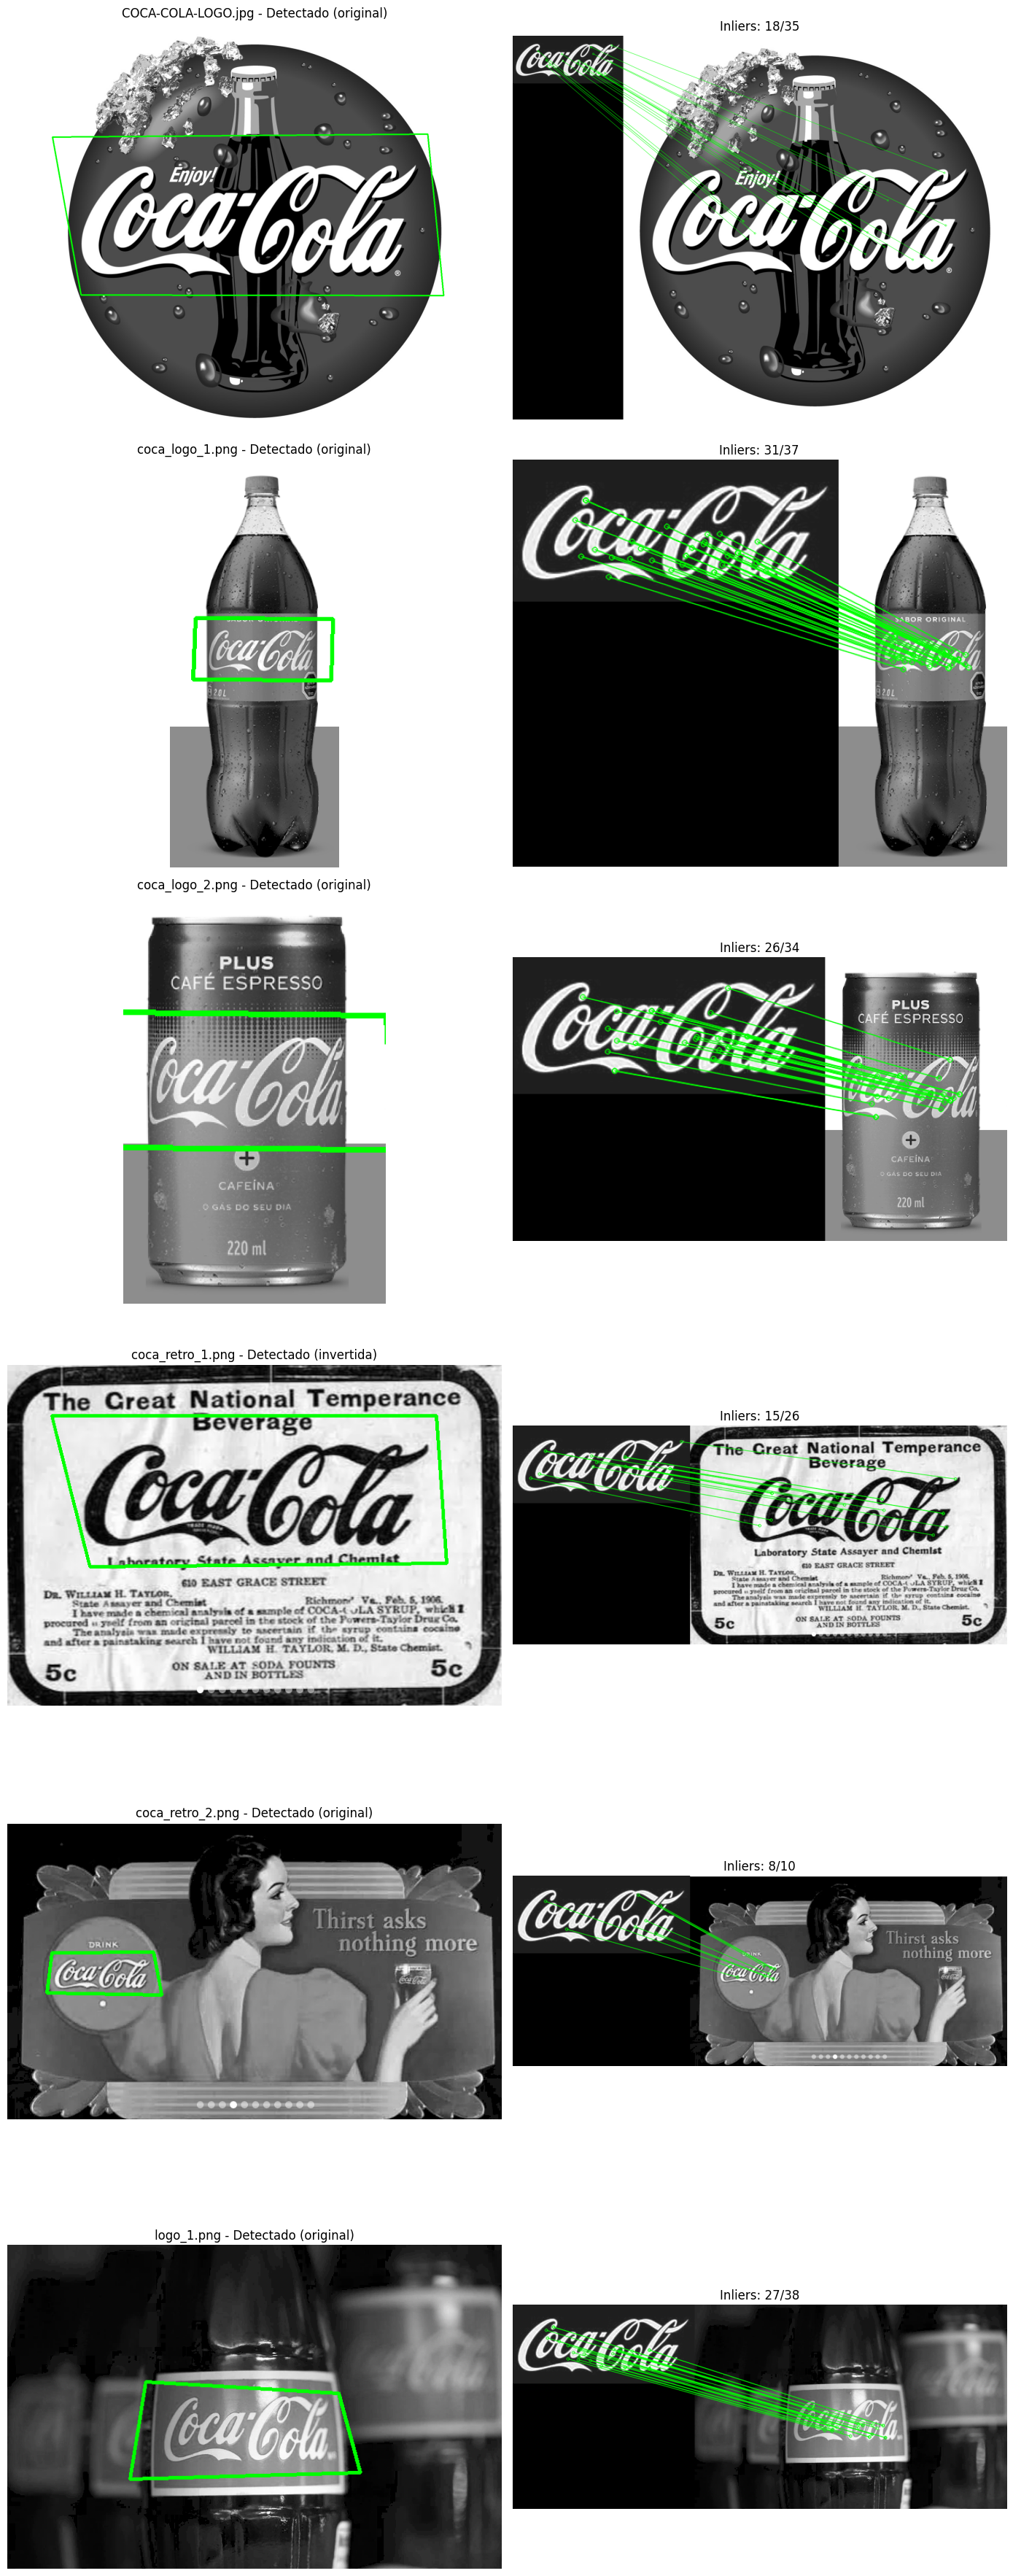

In [4]:

img_template = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
img_template = cv.bitwise_not(img_template)
img_template = cv.convertScaleAbs(img_template, alpha=1.7, beta=30)

images_dir = 'images'
image_extensions = {'.png', '.jpg', '.jpeg'}
resultados = []

for filename in sorted(os.listdir(images_dir)):
    if Path(filename).suffix.lower() not in image_extensions:
        continue
    
    img_path = os.path.join(images_dir, filename)
    img_search = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    

    
    print(f"\nProcesando: {filename}")

    
    # Detectar logo
    resultado = detectar_logo(img_template, img_search)
    
    if resultado:
        resultado['filename'] = filename
        resultado['imagen_original'] = img_search
        resultados.append(resultado)
    else:
        print(f"No se detectó logo en {filename}\n")


print(f"RESULTADOS: {len(resultados)}/{len([f for f in os.listdir(images_dir) if Path(f).suffix.lower() in image_extensions])} imágenes procesadas")



fig, axes = plt.subplots(len(resultados), 2, figsize=(14, 6 * len(resultados)))

if len(resultados) == 1:
    axes = axes.reshape(1, -1)

for idx, resultado in enumerate(resultados):

    img_search_color = cv.cvtColor(resultado['imagen_original'], cv.COLOR_GRAY2BGR)
    img_marked = cv.polylines(
        img_search_color.copy(),
        [np.int32(resultado['puntos_esquina'])],
        True, (0, 255, 0), 3
    )
    axes[idx, 0].imshow(cv.cvtColor(img_marked, cv.COLOR_BGR2RGB))
    axes[idx, 0].set_title(f"{resultado['filename']} - Detectado ({resultado['intento']})")
    axes[idx, 0].axis('off')
    
    # Derecha: Matches
    draw_params = dict(
        matchColor=(0, 255, 0),
        singlePointColor=None,
        matchesMask=resultado['mask'].ravel().tolist(),
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    img_matches = cv.drawMatches(
        img_template, resultado['keypoints1'],
        resultado['imagen_original'], resultado['keypoints2'],
        resultado['matches'], None, **draw_params
    )
    axes[idx, 1].imshow(img_matches)
    inliers = sum(resultado['mask'].ravel().tolist())
    axes[idx, 1].set_title(f"Inliers: {inliers}/{len(resultado['matches'])}")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()


### Punto 2

En este escenario, la estrategia se basa en Template Matching complementado con un procesamiento multi-escala y un mecanismo de eliminación de redundancias mediante Non-Maximum Suppression (NMS), permitiendo detectar múltiples instancias del logo dentro de una misma imagen aun cuando existan variaciones de tamaño o leves diferencias en iluminación.

El procedimiento comienza con un preprocesamiento tanto del template como de la imagen de búsqueda. Ambos se convierten a escala de grises y se suavizan mediante Gaussian Blur con el objetivo de reducir ruido antes de la extracción de bordes. Posteriormente, se aplica el detector de bordes Canny, dado que Template Matching opera de manera más estable sobre mapas de bordes, los cuales presentan mayor consistencia frente a variaciones de color, sombras o iluminación. Con este preprocesamiento, tanto el template como la imagen adquieren una representación estructural centrada en contornos, facilitando la correlación entre ambos.

Dado que se quiere implementar un algoritmo que sea generalizable para distintas imagenes que no necesariamente tienen el mismo tamaño del logo, se genera una serie de escalas entre el 20% y el 80% del tamaño original del template. Para cada escala, se calcula la correlación cruzada normalizada utilizando el método TM_CCOEFF_NORMED, que es robusto frente a variaciones de intensidad. Durante esta iteración, el algoritmo mide el valor máximo de correlación obtenido en cada escala y selecciona como escala óptima aquella que produzca el mayor valor, el cual se interpreta como la configuración más representativa y confiable para el logo en esa imagen.

Con la mejor escala identificada, se realiza una búsqueda de  candidatos aplicando un umbral dinámico equivalente al 77% del valor de confianza máximo obtenido. Todas las posiciones que superan este umbral se consideran posibles instancias del logo. Sin embargo, como estas detecciones suelen generar múltiples rectángulos superpuestos alrededor de la misma región, se aplica Non-Maximum Suppression (NMS) a fin de eliminar duplicados y conservar únicamente aquellas detecciones que representen verdaderas ocurrencias del objeto. NMS ordena las detecciones según su nivel de confianza, selecciona la más alta y descarta las que presenten un solapamiento significativo medido mediante el índice IoU (Intersection over Union). Con un umbral de IoU de 0.6 se garantiza que solo permanezca una detección por cada instancia real del logo.

Finalmente, las detecciones filtradas por NMS se visualizan en la imagen mediante rectángulos verdes junto con su valor de confianza. 

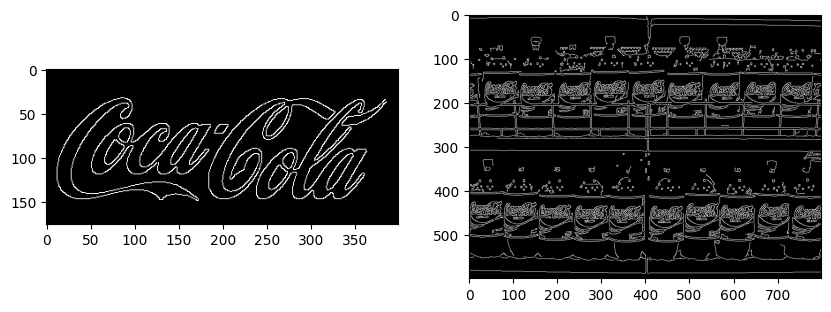

In [5]:
# Cargamos la imagen a procesar
img = cv.imread('images/coca_multi.png')
template = cv.imread('template/pattern.png')

img_rgb= cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_gray= cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

#temple_sin_inverted = cv.bitwise_not(template_gray)
#img_gray_blurred = cv.medianBlur(img_gray,5)

img_gb = cv.GaussianBlur(img_gray,(5,5),0)

template_canny = cv.Canny(template_gray, 50, 200)
img_gray_canny = cv.Canny(img_gb, 25 , 200)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(template_canny,cmap='gray')
plt.subplot(1,2,2)
plt.imshow(img_gray_canny,cmap='gray')

In [6]:
# 
def nms(detections, tresh):
    if not detections:
        return []
    detections = sorted(detections, key=lambda x: x[0], reverse=True)
    keep = []
    
    while detections:
        current = detections.pop(0)
        keep.append(current)
        
        # Calcula IoU con resto
        x1_c, y1_c = current[1]
        x2_c, y2_c = x1_c + current[2], y1_c + current[3]
        area_c = current[2] * current[3]
        
        detections_filtered = []
        for det in detections:
            x1, y1 = det[1]
            x2, y2 = x1 + det[2], y1 + det[3]
            area = det[2] * det[3]
            
            xi1 = max(x1_c, x1)
            yi1 = max(y1_c, y1)
            xi2 = min(x2_c, x2)
            yi2 = min(y2_c, y2)
            
            inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
            union_area = area_c + area - inter_area
            iou = inter_area / union_area if union_area > 0 else 0
            
            if iou < tresh:
                detections_filtered.append(det)
        
        detections = detections_filtered
    
    return keep


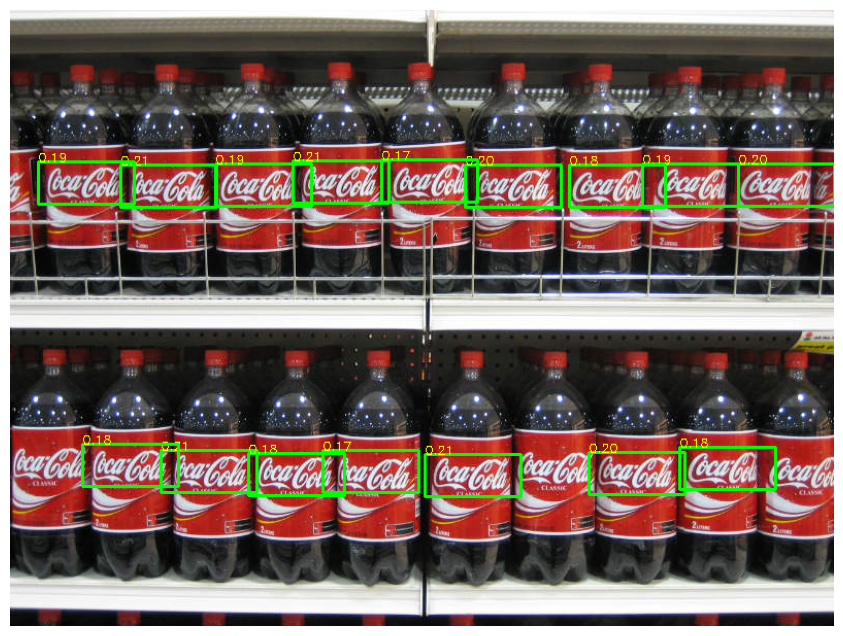

In [7]:

scales = np.linspace(0.2, 0.8, 20)
mejor_escala = None
best_confidence = -1

for s in scales:
    tmpl = cv.resize(template_canny, None, fx=s, fy=s, interpolation=cv.INTER_AREA)
    th, tw = tmpl.shape
    if th > img_gray_canny.shape[0] or tw > img_gray_canny.shape[1]:
        continue
    
    res = cv.matchTemplate(img_gray_canny, tmpl, cv.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
    
    if max_val > best_confidence:
        best_confidence = max_val
        mejor_escala = s


templ_mejor = cv.resize(template_canny, None, fx=mejor_escala, fy=mejor_escala, interpolation=cv.INTER_AREA)
th, tw = templ_mejor.shape

res_best = cv.matchTemplate(img_gray_canny, templ_mejor, cv.TM_CCOEFF_NORMED)

threshold = best_confidence * 0.77  

y_coords, x_coords = np.where(res_best >= threshold)
detections_all = []

for x, y in zip(x_coords, y_coords):
    confidence = res_best[y, x]
    detections_all.append((confidence, (x, y), tw, th, mejor_escala))

detections_nms = nms(detections_all, tresh=0.6)

img_draw = img_rgb.copy()
for max_val, max_loc, tw, th, s_val in detections_nms:
    top_left = max_loc
    bottom_right = (top_left[0] + tw, top_left[1] + th)
    cv.rectangle(img_draw, top_left, bottom_right, (0, 255, 0), 2)
    cv.putText(img_draw, f"{max_val:.2f}", top_left, cv.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

plt.figure(figsize=(14, 8))
plt.imshow(img_draw)
plt.axis('off')
plt.show()


### Punto 3

El enfoque del Punto 3 utiliza Template Matching multiescala directamente sobre imágenes en escala de grises (sin Canny) y evalúa dos variantes del template: normal e invertido. Se elige automáticamente la mejor estrategia según la calidad de las detecciones obtenidas.

- Preprocesamiento: se convierte la imagen a grises y se redimensiona manteniendo el aspecto hasta un lado máximo fijo (para normalizar escalas). El template se suaviza con Gaussian Blur.

- Rango de escalas adaptativo: se analiza la imagen (densidad de bordes y cantidad de componentes), se asume que una imagen compleja presenta mayor cantidad de apariciones del logo, por lo tanto seran de menor tamaño y requieren un rango de escalado de template distinto.

- Dos estrategias: (1) template en gris, (2) template invertido. Para cada una se busca la mejor escala que maximiza la correlación normalizada `TM_CCOEFF_NORMED`.

- Umbral adaptativo: con la mejor escala, se calcula el mapa de correlación y se aplica `threshold = best_confidence * factor`, donde el `factor` se ajusta por escala (más estricto para escalas pequeñas) para reducir falsos positivos.

- Filtrado y NMS: se descartan candidatos por tamaño mínimo/máximo relativo y por estar pegados a bordes. Luego se aplica Non‑Maximum Suppression (IoU=0.4) para eliminar solapamientos redundantes.

- Selección de estrategia: se puntúa cada estrategia combinando confianza promedio, confianza máxima y consistencia. Se elige la de mayor puntuación.

Por ultimo se visualizan los resultados detectados. Para el caso de coca_multi se pudo obtener buenos resultados haciendo uso de una estrategia sin canny. Para el caso de coca_logo_2 no fue posible la detección con ninguna de las opciones de template matching probadas. 


In [224]:
def resize_with_aspect_ratio(image, target_size=720, force_resize=True):
    h, w = image.shape[:2]
    max_dim = max(h, w)
    
    if max_dim <= target_size and not force_resize:
        return image
    
    if h > w:
        new_h = target_size
        new_w = int(w * (target_size / h))
    else:
        new_w = target_size
        new_h = int(h * (target_size / w))
    
    return cv.resize(image, (new_w, new_h), interpolation=cv.INTER_AREA)



In [225]:
def detectar_logo_multiescala(img_path, template, resize_target=720):
    img = cv.imread(img_path)
    if img is None:
        return None
    
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_gray_resized = resize_with_aspect_ratio(img_gray, resize_target)
    
    h_orig, w_orig = img_gray.shape
    h_resized, w_resized = img_gray_resized.shape
    scale_factor_x = w_orig / w_resized
    scale_factor_y = h_orig / h_resized
    
    template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY) if len(template.shape) == 3 else template
    template_gray = cv.GaussianBlur(template_gray, (5,5), 0)
    
    def analizar_contenido_imagen(img):
        edges = cv.Canny(cv.GaussianBlur(img, (5, 5), 0), 25, 200)
        edge_density = np.sum(edges > 0) / (img.shape[0] * img.shape[1])
        
        _, binary = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
        num_labels, _ = cv.connectedComponents(binary)
        object_density = num_labels / (img.shape[0] * img.shape[1] / 1000)
        
        variance = np.var(img) / 255.0
        return edge_density, object_density, variance
    
    edge_density, object_density, variance = analizar_contenido_imagen(img_gray_resized)
    
    if object_density > 0.9:
        scale_min, scale_max, num_scales = 0.2, 1.2, 25
    else:
        scale_min, scale_max, num_scales = 0.55, 2.2, 40
    
    estrategias = [
        {
            'nombre': 'temple_inv',
            'template_proc': cv.bitwise_not(template_gray),
            'imagen_proc': img_gray_resized,
            'scales': np.linspace(scale_min, scale_max, num_scales),
            'threshold_factor': 0.85,
            'min_size_filter': edge_density > 0.1
        },
        {
            'nombre': 'temple_sin_invertido',
            'template_proc': template_gray,
            'imagen_proc': img_gray_resized,
            'scales': np.linspace(scale_min, scale_max, num_scales),
            'threshold_factor': 0.85,
            'min_size_filter': edge_density > 0.1
        }
    ]
    
    resultados_estrategias = []
    
    for estrategia in estrategias:
        mejor_escala = None
        best_confidence = -1
        
        for s in estrategia['scales']:
            tmpl = cv.resize(estrategia['template_proc'], None, fx=s, fy=s, interpolation=cv.INTER_AREA)
            th, tw = tmpl.shape
            
            if th > estrategia['imagen_proc'].shape[0] or tw > estrategia['imagen_proc'].shape[1]:
                continue
            
            res = cv.matchTemplate(estrategia['imagen_proc'], tmpl, cv.TM_CCOEFF_NORMED)
            _, max_val, _, _ = cv.minMaxLoc(res)
            
            if max_val > best_confidence:
                best_confidence = max_val
                mejor_escala = s
        
        if mejor_escala is None:
            continue
        
        tmpl_mejor = cv.resize(estrategia['template_proc'], None, fx=mejor_escala, fy=mejor_escala, interpolation=cv.INTER_AREA)
        th, tw = tmpl_mejor.shape
        res_best = cv.matchTemplate(estrategia['imagen_proc'], tmpl_mejor, cv.TM_CCOEFF_NORMED)
        
        base_threshold = estrategia['threshold_factor']
        if mejor_escala < 0.3:
            adaptive_threshold = base_threshold + 0.08
        elif mejor_escala < 0.5:
            adaptive_threshold = base_threshold + 0.04
        else:
            adaptive_threshold = base_threshold
        
        threshold = best_confidence * adaptive_threshold
        y_coords, x_coords = np.where(res_best >= threshold)
        
        min_detection_size = min(h_resized, w_resized) * 0.025
        max_detection_size = min(h_resized, w_resized) * 0.75
        border_margin = 5
        
        detections_temp = []
        for x, y in zip(x_coords, y_coords):
            confidence = res_best[y, x]
            detection_size = min(tw, th)
            
            if not (min_detection_size <= detection_size <= max_detection_size):
                continue
            if (x < border_margin or y < border_margin or 
                x + tw > estrategia['imagen_proc'].shape[1] - border_margin or 
                y + th > estrategia['imagen_proc'].shape[0] - border_margin):
                continue
                
            detections_temp.append((confidence, (x, y), tw, th, mejor_escala))
        
        detections_nms_temp = nms(detections_temp, tresh=0.4)
        
        if len(detections_nms_temp) > 0:
            confianza_promedio = np.mean([d[0] for d in detections_nms_temp])
            confianza_min = np.min([d[0] for d in detections_nms_temp])
            consistencia = confianza_min / best_confidence
            puntuacion = confianza_promedio * 0.6 + best_confidence * 0.3 + consistencia * 0.1
        else:
            puntuacion = 0
        
        resultados_estrategias.append({
            'estrategia': estrategia,
            'escala': mejor_escala,
            'confianza': best_confidence,
            'nombre': estrategia['nombre'],
            'detecciones': detections_nms_temp,
            'puntuacion': puntuacion
        })
    
    if not resultados_estrategias:
        return None
    
    mejor_resultado = max(resultados_estrategias, key=lambda x: x['puntuacion'])
    detections_nms = mejor_resultado['detecciones']
    
    if not detections_nms:
        return None
    
    detections_scaled = []
    for conf, (x, y), w, h, s in detections_nms:
        x_orig = int(x * scale_factor_x)
        y_orig = int(y * scale_factor_y)
        w_orig = int(w * scale_factor_x)
        h_orig = int(h * scale_factor_y)
        detections_scaled.append((conf, (x_orig, y_orig), w_orig, h_orig, s))
    
    return {
        'imagen_original': img_rgb,
        'detecciones_originales': detections_scaled,
        'estrategia_usada': mejor_resultado['nombre'],
        'max_confianza': mejor_resultado['confianza'],
        'mejor_escala': mejor_resultado['escala']
    }

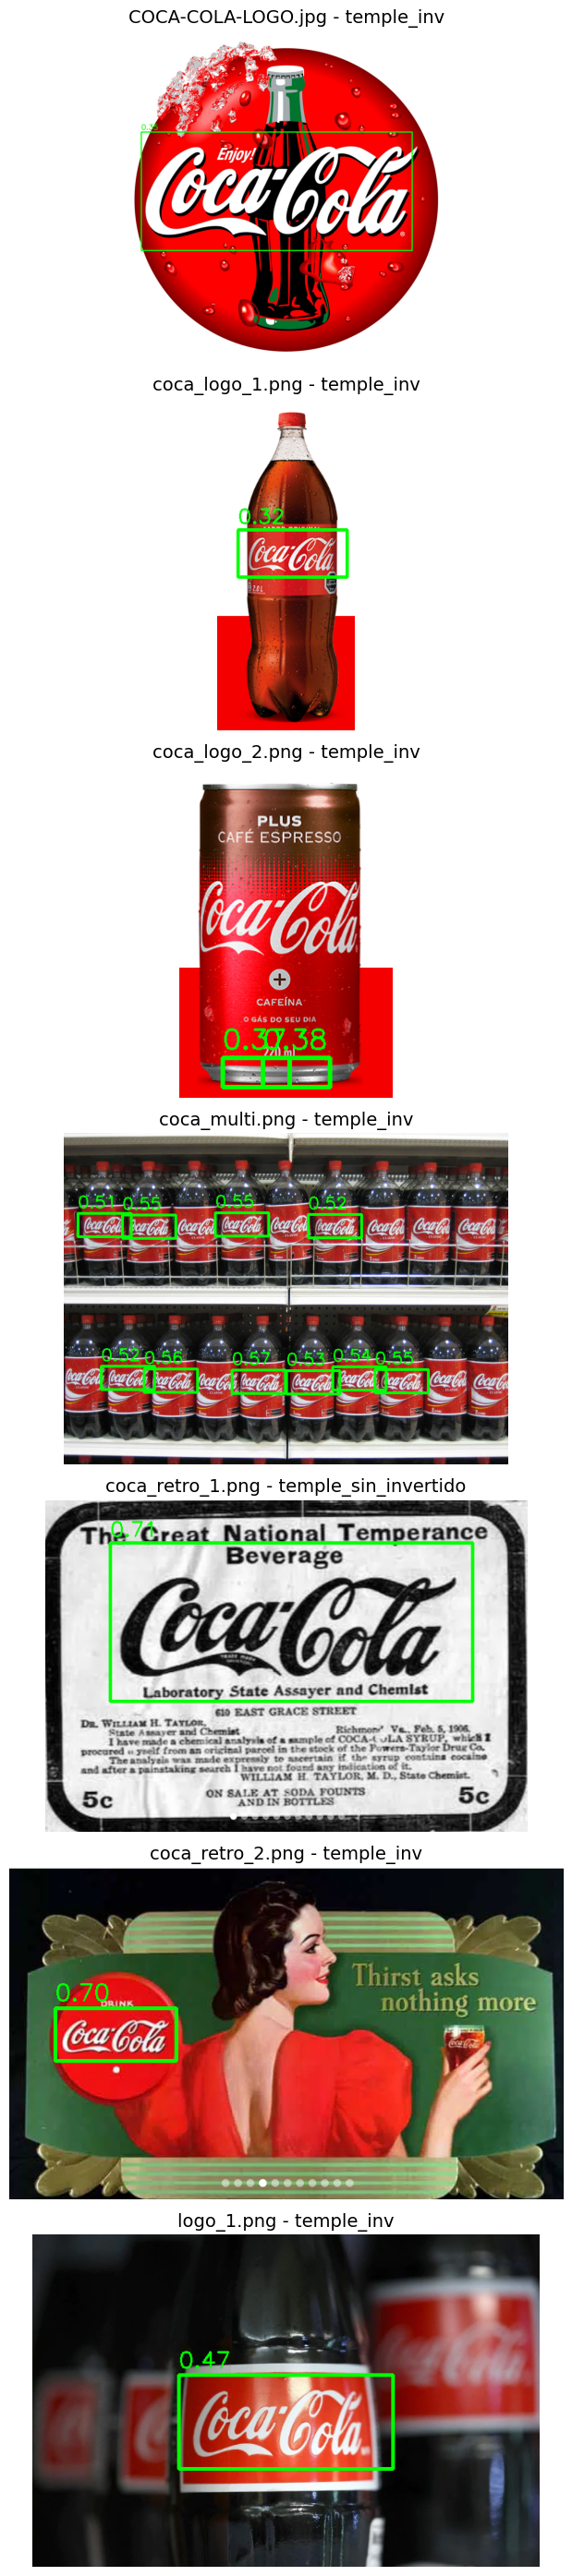

In [226]:
template = cv.imread('template/pattern.png')
imagenes = sorted([f for f in os.listdir('images') if Path(f).suffix.lower() in {'.png', '.jpg'}])
resultados = []

for img_name in imagenes:
    resultado = detectar_logo_multiescala(f'images/{img_name}', template, 1080)
    if resultado:
        resultados.append({'nombre': img_name, 'resultado': resultado})

if resultados:
    fig, axes = plt.subplots(len(resultados), 1, figsize=(12, 4 * len(resultados)))
    
    if len(resultados) == 1:
        axes = [axes]
    
    for idx, item in enumerate(resultados):
        img_name = item['nombre']
        resultado = item['resultado']
        
        img_draw = resultado['imagen_original'].copy()
        for conf, loc, w, h, s in resultado['detecciones_originales']:
            cv.rectangle(img_draw, loc, (loc[0] + w, loc[1] + h), (0, 255, 0), 3)
            cv.putText(img_draw, f"{conf:.2f}", (loc[0], loc[1]-10), 
                      cv.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
        
        axes[idx].imshow(img_draw)
        axes[idx].set_title(f"{img_name} - {resultado['estrategia_usada']}", fontsize=14)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()